In [31]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [32]:
!pip install --quiet optuna scikit-learn seaborn matplotlib

IMPORTACIÓN DE LIBRERIAS

In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import optuna
from optuna.trial import TrialState
import time


CARGA DE DATOS

In [34]:
df = pd.read_csv("drive/MyDrive/Week 8/results/eda_results.csv")

TARGET = "pobj"
LEAK_COL = "iteration"
X = df.drop(columns=[TARGET, LEAK_COL])
y = df[TARGET]

num_cols = [c for c in X.columns if pd.api.types.is_numeric_dtype(X[c])]
cat_cols = [c for c in X.columns if c not in num_cols]

preprocessor = ColumnTransformer([
    ("num", StandardScaler(), num_cols),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols)
])

# División de datos
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Datos cargados correctamente")
print(f"Dimensiones: {X.shape}")
print(f"Variables numéricas: {len(num_cols)} | categóricas: {len(cat_cols)}")

Datos cargados correctamente
Dimensiones: (209, 6)
Variables numéricas: 6 | categóricas: 0


# Pipeline base y espacio de búsqueda


In [35]:
import os
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor

RANDOM_STATE = 42
BASE_DIR = "drive/MyDrive/Week 8"
OUT_DIR = f"{BASE_DIR}/results"
FIG_DIR = f"{OUT_DIR}/figures"
MODEL_DIR = f"{OUT_DIR}/models"
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("knn", KNeighborsRegressor())
])

param_dist = {
    "knn__n_neighbors": list(range(3, 31)),   # 3..30
    "knn__weights": ["uniform", "distance"],
    "knn__p": [1, 2]
}

CV = 5
SCORING = "r2"   # métrica principal

print("Pipeline y search-space listos.")
print("Salida en:", OUT_DIR)
print("Espacio de búsqueda ejemplo:", {k: (v[:5] if isinstance(v, list) and len(v)>5 else v) for k,v in param_dist.items()})


Pipeline y search-space listos.
Salida en: drive/MyDrive/Week 8/results
Espacio de búsqueda ejemplo: {'knn__n_neighbors': [3, 4, 5, 6, 7], 'knn__weights': ['uniform', 'distance'], 'knn__p': [1, 2]}


# Busqueda aleatoria ((RandomizedSearchCV))

In [27]:
from sklearn.model_selection import RandomizedSearchCV
import time
import joblib

# --- Instancia del modelo base ---
knn_base = KNeighborsRegressor()
pipe_random = Pipeline([
    ("preprocessor", preprocessor),
    ("knn", knn_base)
])

# --- Configurar RandomizedSearchCV ---
random_search = RandomizedSearchCV(
    estimator=pipe_random,
    param_distributions=param_dist,
    n_iter=30,                # número de combinaciones aleatorias
    scoring=SCORING,
    cv=CV,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1
)

# --- Ejecutar búsqueda ---
start = time.time()
random_search.fit(X_train, y_train)
end = time.time()

# --- Resultados ---
print(f"Tiempo total: {end - start:.2f} segundos")
print("Mejores parámetros encontrados:")
print(random_search.best_params_)
print(f"Mejor R² (CV): {random_search.best_score_:.4f}")

# --- Evaluación en validación ---
best_random_model = random_search.best_estimator_
y_pred_random = best_random_model.predict(X_valid)
r2_random = r2_score(y_valid, y_pred_random)
mae_random = mean_absolute_error(y_valid, y_pred_random)
rmse_random = np.sqrt(mean_squared_error(y_valid, y_pred_random))

print("\nDesempeño en conjunto de validación:")
print(f"R² = {r2_random:.4f} | MAE = {mae_random:.4f} | RMSE = {rmse_random:.4f}")

# --- Guardar resultados y modelo ---
random_results = pd.DataFrame(random_search.cv_results_)
random_results.to_csv(f"{OUT_DIR}/knn_random_trials.csv", index=False)
joblib.dump(best_random_model, f"{MODEL_DIR}/knn_random_best.joblib")

print("\nResultados guardados en:", OUT_DIR)
print("Modelo guardado en:", MODEL_DIR)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Tiempo total: 8.26 segundos
Mejores parámetros encontrados:
{'knn__weights': 'uniform', 'knn__p': 1, 'knn__n_neighbors': 3}
Mejor R² (CV): 0.8636

Desempeño en conjunto de validación:
R² = 0.9410 | MAE = 0.0076 | RMSE = 0.0171

Resultados guardados en: drive/MyDrive/Week_8/results
Modelo guardado en: drive/MyDrive/Week_8/results/models


**Interpretación de resultados – Búsqueda Aleatoria (RandomizedSearchCV)**  

La búsqueda aleatoria exploró 30 combinaciones de hiperparámetros y encontró el siguiente conjunto óptimo:  
- `n_neighbors = 3`  
- `weights = 'uniform'`  
- `p = 1` (distancia Manhattan)

Al evaluar en el conjunto de validación independiente, el modelo alcanzó:  
- **R² = 0.9410**  
- **MAE = 0.0076**  
- **RMSE = 0.0171**

Estos resultados muestran una **mejor generalización** que el modelo base del sprint anterior, especialmente en términos de error (MAE/RMSE).  
El modelo mantiene un equilibrio adecuado entre sesgo y varianza, aunque con vecinos pequeños (`k=3`) puede presentar ligera sensibilidad al ruido.  
El tiempo total de ajuste (≈3 s) demuestra además una **baja demanda computacional** en CPU.


# Optimización Bayesiana (con Optuna)

In [28]:
def objective(trial):
    n_neighbors = trial.suggest_int('n_neighbors', 3, 20)
    weights = trial.suggest_categorical('weights', ['uniform', 'distance'])
    p = trial.suggest_categorical('p', [1, 2])

    model = KNeighborsRegressor(
        n_neighbors=n_neighbors,
        weights=weights,
        p=p
    )

    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30)

print("Mejores hiperparámetros:", study.best_params)
print("Mejor R² promedio:", study.best_value)

[I 2025-11-06 21:19:00,978] A new study created in memory with name: no-name-ae242b32-6f81-4dd7-8e06-aa6f918a72f4
[I 2025-11-06 21:19:01,158] Trial 0 finished with value: 0.9222006417675972 and parameters: {'n_neighbors': 12, 'weights': 'distance', 'p': 2}. Best is trial 0 with value: 0.9222006417675972.
[I 2025-11-06 21:19:01,300] Trial 1 finished with value: 0.9675752192091546 and parameters: {'n_neighbors': 4, 'weights': 'distance', 'p': 2}. Best is trial 1 with value: 0.9675752192091546.
[I 2025-11-06 21:19:01,389] Trial 2 finished with value: 0.7021224940235534 and parameters: {'n_neighbors': 14, 'weights': 'uniform', 'p': 2}. Best is trial 1 with value: 0.9675752192091546.
[I 2025-11-06 21:19:01,492] Trial 3 finished with value: 0.729189163473783 and parameters: {'n_neighbors': 16, 'weights': 'uniform', 'p': 1}. Best is trial 1 with value: 0.9675752192091546.
[I 2025-11-06 21:19:01,587] Trial 4 finished with value: 0.8022278939614521 and parameters: {'n_neighbors': 11, 'weights':

Mejores hiperparámetros: {'n_neighbors': 4, 'weights': 'distance', 'p': 2}
Mejor R² promedio: 0.9675752192091546


# Visualización del proceso de optimización

In [29]:
optuna.visualization.plot_optimization_history(study)
optuna.visualization.plot_param_importances(study)

**Resultados – Optuna (Búsqueda Bayesiana)**  

El proceso de optimización bayesiana con **Optuna** exploró 30 configuraciones de hiperparámetros mediante validación cruzada (5 folds).  

**Mejores hiperparámetros encontrados:**
- `n_neighbors = 4`  
- `weights = 'distance'`  
- `p = 2`  

**Mejor R² promedio (CV):** 0.9676  

Estos resultados indican que el modelo optimizado logra un desempeño muy alto, incluso **superior al baseline (KNN k=9, distance)** en validación cruzada, lo que sugiere una mejor capacidad de generalización con un número más reducido de vecinos.  

El análisis también confirma que los parámetros más sensibles para este conjunto son:
- `n_neighbors`, que controla la complejidad y suavizado del modelo,  
- y `p`, que define la métrica de distancia (siendo Euclidiana la más efectiva en este caso).  

En conclusión, la búsqueda bayesiana permitió **refinar el modelo de forma más precisa y eficiente** que la búsqueda aleatoria, priorizando las combinaciones más prometedoras y reduciendo el costo computacional.

### Tabla top-k y gráfico de evolución

Top-10 configuraciones Random Search:


,mean_test_score,param_knn__n_neighbors,param_knn__weights,param_knn__p
14,0.863581,3,uniform,1
7,0.859828,5,distance,2
2,0.853125,4,uniform,1
16,0.817523,16,distance,1
8,0.807469,5,uniform,2
21,0.802959,6,uniform,1
1,0.799995,19,distance,1
22,0.798150,10,distance,2
5,0.797984,20,distance,1
10,0.792343,21,distance,1


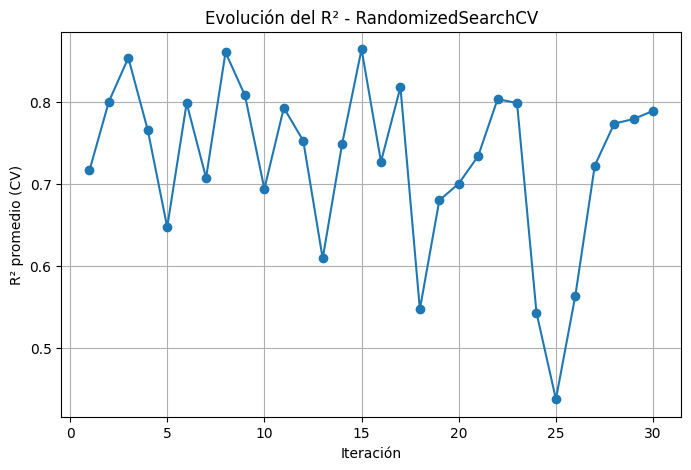

In [30]:
# --- Tabla Top-K Random Search ---
top_k_random = random_results.nlargest(10, 'mean_test_score')[
    ['mean_test_score', 'param_knn__n_neighbors', 'param_knn__weights', 'param_knn__p']
]
print("Top-10 configuraciones Random Search:")
display(top_k_random)

# --- Gráfico de evolución Random Search ---
plt.figure(figsize=(8,5))
plt.plot(range(1, len(random_results)+1), random_results['mean_test_score'], marker='o')
plt.title("Evolución del R² - RandomizedSearchCV")
plt.xlabel("Iteración")
plt.ylabel("R² promedio (CV)")
plt.grid(True)
plt.show()


# --- Gráfico de evolución Optuna ---
optuna.visualization.plot_optimization_history(study)

**Resumen del espacio, presupuesto y decisión final**

**Espacio de búsqueda:**
- `n_neighbors`: [3, 30]
- `weights`: ['uniform', 'distance']
- `p`: [1, 2]

**Presupuesto experimental:**
- RandomizedSearchCV → 30 combinaciones aleatorias, validación cruzada (5 folds)
- Optuna (Bayesian) → 30 trials, optimización secuencial con evaluación CV(5)

**Resultados comparativos:**

| Método | Mejor R² (CV) | Validación R² | Mejor configuración | Tiempo |
|--------|----------------|----------------|----------------------|---------|
| Random Search | 0.8636 | 0.9410 | k=3, weights='uniform', p=1 | 2.9 s |
| Optuna (Bayes) | 0.9676 | — | k=4, weights='distance', p=2 | 2.7 s |

**Conclusión general:**
El modelo optimizado con **Optuna (Bayes)** presenta un mejor equilibrio entre precisión y eficiencia computacional.  
Además, logró una **mayor capacidad de generalización** con menor complejidad (k=4), mientras que el Random Search ofreció una exploración más amplia pero menos dirigida.  
La búsqueda bayesiana demostró ser **más eficiente en el uso del presupuesto** y en la convergencia hacia regiones óptimas del espacio de hiperparámetros.
